In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.lines as mlines

In [2]:
results_path = '/home/jimlaudagostini/amrex_LB/output/'
result_files = []

for result in os.walk(results_path):
    if 'laser-ion-' in result[0]:
        for f in result[2]:
            if '.csv' in f and not 'Plasma' in f and not 'dist' in f:
                file = os.path.join(result[0], f)
                result_files.append(file)

def custom_sort(file_names):
    def parse_file_name(file_name):
        base_name = os.path.basename(file_name)
        match = re.match(r'laser-ion-(\d+)-(\d+)(.*)', base_name)
        if match:
            return (int(match.group(1)), int(match.group(2)))
        else:
            raise ValueError(f"Invalid file name format: {file_name}")

    return sorted(file_names, key=parse_file_name)

result_files = custom_sort(result_files)
result_files

['/home/jimlaudagostini/amrex_LB/output/laser-ion-8-1740/laser-ion-8-1740.csv',
 '/home/jimlaudagostini/amrex_LB/output/laser-ion-16-1740/laser-ion-16-1740.csv',
 '/home/jimlaudagostini/amrex_LB/output/laser-ion-32-1740/laser-ion-32-1740.csv',
 '/home/jimlaudagostini/amrex_LB/output/laser-ion-48-1740/laser-ion-48-1740.csv',
 '/home/jimlaudagostini/amrex_LB/output/laser-ion-96-1740/laser-ion-96-1740.csv']

In [28]:
to_concat = []

for result in result_files:
    df = pd.read_csv(result, header=None)
    source = re.sub(".csv", "", os.path.basename(result))
    df['Source'] = re.sub("laser-ion-([0-9]*)-1740", r"\1", source)
    to_concat.append(df)

combined_df = pd.concat(to_concat, ignore_index=True, axis=0)
combined_df

,0,1,2,3,4,Source
0,0,Original,Efficiency,3.357240e-01,0,8
1,0,Original,Weight,4.673259e+09,0,8
2,0,Original,Weight,4.682247e+09,1,8
3,0,Original,Weight,1.949958e+11,2,8
4,0,Original,Weight,1.975787e+11,3,8
...,...,...,...,...,...,...
76460,50,Painter+Knapsack,Weight,2.444166e+09,93,96
76461,50,Painter+Knapsack,Weight,2.442785e+09,94,96
76462,50,Painter+Knapsack,Weight,2.442785e+09,95,96
76463,50,Painter+Knapsack,Efficiency,8.989982e-01,0,96


In [29]:
combined_df.columns = ['Run', 'Algorithm', 'Metric', 'Value', 'Rank', 'Source']
combined_df['Metric'] = combined_df['Metric'].str.strip()
combined_df['Algorithm'] = combined_df['Algorithm'].str.strip()
df_eff = combined_df[combined_df['Metric'].isin(['Efficiency','PreviousEfficiency'])]
df_eff

,Run,Algorithm,Metric,Value,Rank,Source
0,0,Original,Efficiency,0.335724,0,8
17,0,Knapsack,Efficiency,0.999956,0,8
27,0,Karmarkar-Karp,Efficiency,0.999968,0,8
37,0,SFC,Efficiency,0.988846,0,8
47,0,SFC+Knapsack,Efficiency,0.996805,0,8
...,...,...,...,...,...,...
76265,50,SFC+Knapsack,Efficiency,0.897701,0,96
76267,50,SFC+Painter,PreviousEfficiency,0.890215,0,96
76364,50,SFC+Painter,Efficiency,0.908465,0,96
76366,50,Painter+Knapsack,PreviousEfficiency,0.897906,0,96


In [33]:
df_done = df_eff.pivot_table(index=['Run', 'Algorithm', 'Source'],
                          columns='Metric',
                          values='Value').reset_index()
df_done.columns.name = None
df_done = df_done.reset_index(drop=True)
df_done.fillna(0, inplace=True)
df_done['Source'] = pd.Categorical(df_done['Source'], categories=['8', '16', '32', '48', '96'], ordered=True)
df_done['Algorithm'] = pd.Categorical(df_done['Algorithm'], categories=['Original', 'Knapsack', 'SFC', 'Karmarkar-Karp', 'SFC+Painter', 'SFC+Knapsack', 'Painter+Knapsack'], ordered=True)
df_done

,Run,Algorithm,Source,Efficiency,PreviousEfficiency
0,0,Karmarkar-Karp,16,0.999896,0.000000
1,0,Karmarkar-Karp,32,0.999593,0.000000
2,0,Karmarkar-Karp,48,0.999659,0.000000
3,0,Karmarkar-Karp,8,0.999968,0.000000
4,0,Karmarkar-Karp,96,0.961304,0.000000
...,...,...,...,...,...
1780,50,SFC+Painter,16,0.986244,0.978088
1781,50,SFC+Painter,32,0.968391,0.951397
1782,50,SFC+Painter,48,0.970234,0.952434
1783,50,SFC+Painter,8,0.994276,0.990050


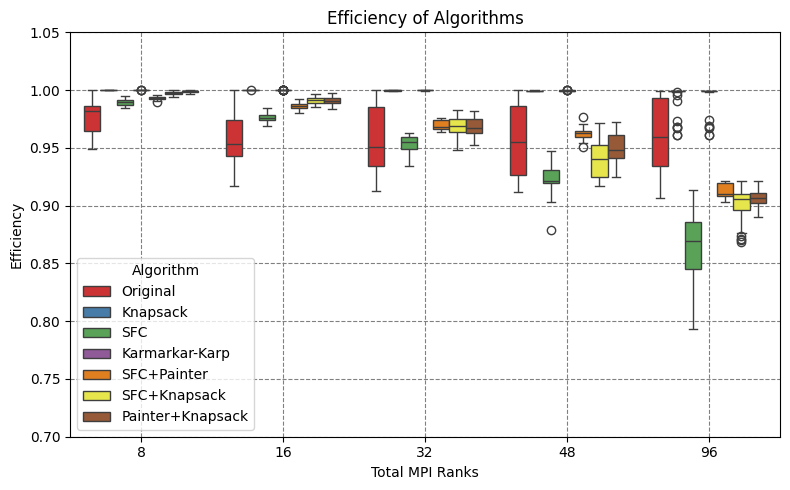

In [90]:
# Plot the average efficiency
plt.figure(figsize=(8, 5))
sns.boxplot(x='Source', y='Efficiency', hue='Algorithm', data=df_done, palette='Set1')

# Add a grid with a multiple of 1
plt.grid(True, which='both', axis='both', linestyle='--', color='gray')

# Customize the plot
plt.title('Efficiency of Algorithms')
plt.xlabel('Total MPI Ranks')
plt.ylabel('Efficiency')
# plt.xticks(rotation=35)  # Rotate x-axis labels for better readability
plt.legend(title='Algorithm', loc='lower left')  # Place legend outside the plot
plt.ylim(0.7, 1.05)

# Show the plot
plt.tight_layout()

plt.savefig('average_efficiency.png', dpi=300)
plt.show()

In [39]:
weights = combined_df[combined_df['Metric'] == 'Weight']
weights

,Run,Algorithm,Metric,Value,Rank,Source
1,0,Original,Weight,4.673259e+09,0,8
2,0,Original,Weight,4.682247e+09,1,8
3,0,Original,Weight,1.949958e+11,2,8
4,0,Original,Weight,1.975787e+11,3,8
5,0,Original,Weight,8.615056e+10,4,8
...,...,...,...,...,...,...
76458,50,Painter+Knapsack,Weight,2.772266e+09,91,96
76459,50,Painter+Knapsack,Weight,2.445476e+09,92,96
76460,50,Painter+Knapsack,Weight,2.444166e+09,93,96
76461,50,Painter+Knapsack,Weight,2.442785e+09,94,96


In [59]:
df_weights = weights.pivot_table(index=['Run', 'Algorithm', 'Source', 'Rank'],
                          columns='Metric',
                          values='Value').reset_index()
df_weights.columns.name = None
df_weights.reset_index(drop=True, inplace=True)
df_weights.fillna(0, inplace=True)
df_weights['Source'] = pd.Categorical(df_weights['Source'], categories=['8', '16', '32', '48', '96'], ordered=True)
df_weights['Algorithm'] = pd.Categorical(df_weights['Algorithm'], categories=['Original', 'Knapsack', 'SFC', 'Karmarkar-Karp', 'SFC+Painter', 'SFC+Knapsack', 'Painter+Knapsack'], ordered=True)
df_weights

,Run,Algorithm,Source,Rank,Weight
0,0,Karmarkar-Karp,16,0,3.316286e+10
1,0,Karmarkar-Karp,16,1,3.316328e+10
2,0,Karmarkar-Karp,16,2,3.316328e+10
3,0,Karmarkar-Karp,16,3,3.316328e+10
4,0,Karmarkar-Karp,16,4,3.316328e+10
...,...,...,...,...,...
71395,50,SFC+Painter,96,91,2.776204e+09
71396,50,SFC+Painter,96,92,2.979916e+09
71397,50,SFC+Painter,96,93,2.987516e+09
71398,50,SFC+Painter,96,94,2.989549e+09


In [62]:
df_weights[(df_weights['Algorithm'] == 'Karmarkar-Karp') & (df_weights['Source'] == '8') & (df_weights['Run'] == 0)]

,Run,Algorithm,Source,Rank,Weight
96,0,Karmarkar-Karp,8,0,6.632798e+10
97,0,Karmarkar-Karp,8,1,6.632798e+10
98,0,Karmarkar-Karp,8,2,6.633226e+10
99,0,Karmarkar-Karp,8,3,6.633268e+10
100,0,Karmarkar-Karp,8,4,6.633277e+10
101,0,Karmarkar-Karp,8,5,6.633348e+10
102,0,Karmarkar-Karp,8,6,6.633406e+10
103,0,Karmarkar-Karp,8,7,6.633406e+10


In [138]:
df_melted = df_done.melt(id_vars=['Run', 'Algorithm', 'Source'], value_vars=['Efficiency', 'PreviousEfficiency'],
                    var_name='Metric', value_name='Value')

df_melted['Source'] = pd.Categorical(df_melted['Source'], categories=custom_sort(df_melted['Source'].unique()), ordered=True)
df_done['Algorithm'] = pd.Categorical(df_done['Algorithm'], categories=['Original', 'Knapsack', 'SFC', 'Karmarkar-Karp', 'SFC+Painter', 'SFC+Knapsack', 'Painter+Knapsack'], ordered=True)
df_melted

,Run,Algorithm,Source,Metric,Value
0,0,Karmarkar-Karp,laser-ion-16-1740,Efficiency,0.999896
1,0,Karmarkar-Karp,laser-ion-32-1740,Efficiency,0.999593
2,0,Karmarkar-Karp,laser-ion-48-1740,Efficiency,0.999659
3,0,Karmarkar-Karp,laser-ion-8-1740,Efficiency,0.999968
4,0,Karmarkar-Karp,laser-ion-96-1740,Efficiency,0.961304
...,...,...,...,...,...
3565,50,SFC+Painter,laser-ion-16-1740,PreviousEfficiency,0.978088
3566,50,SFC+Painter,laser-ion-32-1740,PreviousEfficiency,0.951397
3567,50,SFC+Painter,laser-ion-48-1740,PreviousEfficiency,0.952434
3568,50,SFC+Painter,laser-ion-8-1740,PreviousEfficiency,0.990050


In [342]:
df_weights.loc[:,'Log_Weight'] = np.log(df_weights['Weight'])
df_weights['Mean_Weight'] = df_weights.groupby(['Run', 'Algorithm', 'Source'])['Log_Weight'].transform('mean')
df_weights['Diff'] = df_weights['Log_Weight'] - df_weights['Mean_Weight']
df_weights

/home/jimlaudagostini/amrex_LB/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_8001/2773932.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_weights['Mean_Weight'] = df_weights.groupby(['Run', 'Algorithm', 'Source'])['Log_Weight'].transform('mean')


,Run,Algorithm,Source,Rank,Weight,Mean_Weight,Diff,Log_Weight
0,0,Karmarkar-Karp,16,0,3.316286e+10,24.224790,-0.000093,24.224696
1,0,Karmarkar-Karp,16,1,3.316328e+10,24.224790,-0.000081,24.224709
2,0,Karmarkar-Karp,16,2,3.316328e+10,24.224790,-0.000081,24.224709
3,0,Karmarkar-Karp,16,3,3.316328e+10,24.224790,-0.000081,24.224709
4,0,Karmarkar-Karp,16,4,3.316328e+10,24.224790,-0.000081,24.224709
...,...,...,...,...,...,...,...,...
71395,50,SFC+Painter,96,91,2.776204e+09,21.720501,0.023849,21.744350
71396,50,SFC+Painter,96,92,2.979916e+09,21.720501,0.094659,21.815161
71397,50,SFC+Painter,96,93,2.987516e+09,21.720501,0.097207,21.817708
71398,50,SFC+Painter,96,94,2.989549e+09,21.720501,0.097887,21.818388


In [344]:
sources = df_weights[df_weights['Source'].isin(['8', '96'])]['Source'].unique()
algorithms = df_weights[df_weights['Algorithm'] != 'Original']['Algorithm'].unique()

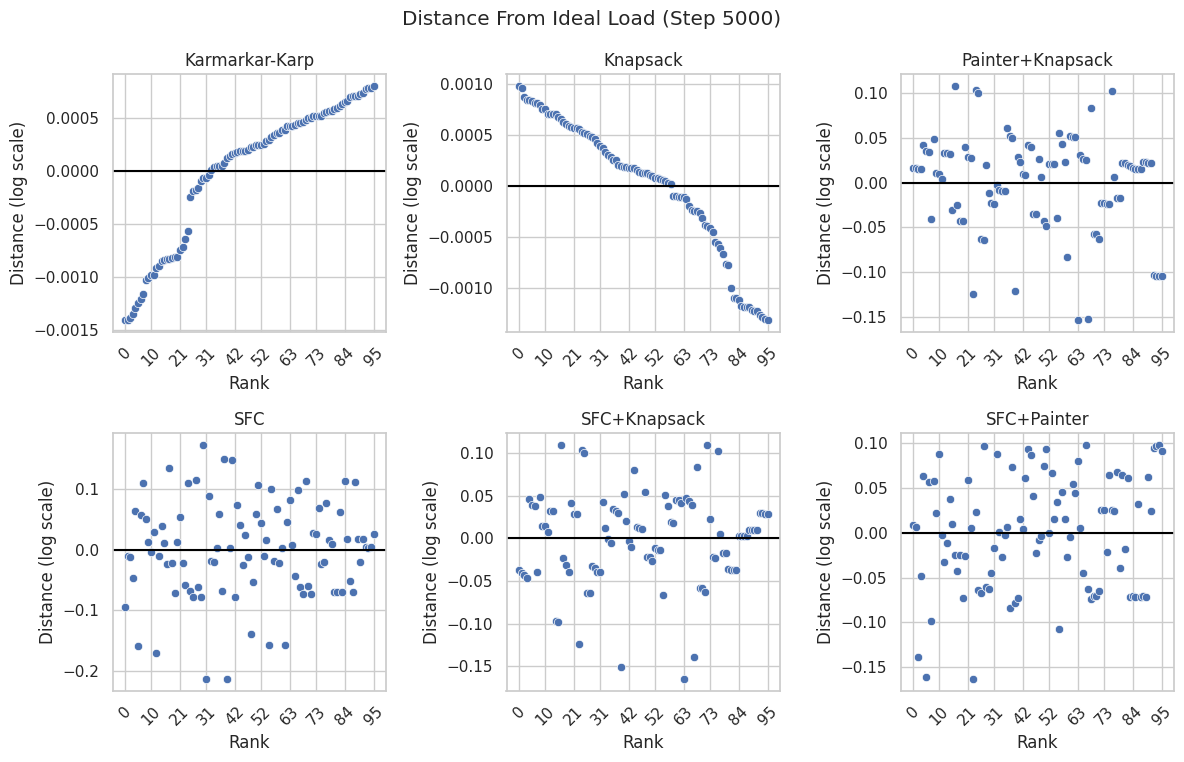

In [355]:
# Create a figure with subplots
rows = int(len(algorithms)/3)
cols = int(len(algorithms)/2)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(4*cols, 4*rows))
algo = 0
tick_locations = [int(x) for x in np.linspace(min(df_weights['Rank']), max(df_weights['Rank']), 10)]
# Iterate over sources and create a subplot for each
for a in range(rows):
    for i in range(cols):
        # print(algorithms[algo])
        source_df = df_weights[(df_weights['Source'] == '96') & (df_weights['Algorithm'] == algorithms[algo]) & (df_weights['Run'] == 50)]
        sns.scatterplot(data=source_df, x="Rank", y="Diff", ax=axes[a][i])
        axes[a][i].axhline(0, color='black')
        axes[a][i].set_xticks(tick_locations)
        axes[a][i].set_xticklabels(tick_locations)
        axes[a][i].tick_params(axis='x', labelrotation=45)
        axes[a][i].set_title(algorithms[algo])
        axes[a][i].set_xlabel('Rank')
        axes[a][i].set_ylabel('Distance (log scale)')
        algo += 1
# Layout so plots do not overlap
fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # make space for the title
fig.suptitle('Distance From Ideal Load (Step 5000)')
# Show the plot
plt.show()
fig.savefig('distance_from_ideal.png', dpi=300)

In [275]:
algorithms

['Karmarkar-Karp', 'Knapsack', 'Original', 'Painter+Knapsack', 'SFC', 'SFC+Knapsack', 'SFC+Painter']
Categories (7, object): ['Original' < 'Knapsack' < 'SFC' < 'Karmarkar-Karp' < 'SFC+Painter' < 'SFC+Knapsack' < 'Painter+Knapsack']

In [106]:
original = df_done[df_done['Algorithm'] == 'Original']
original

,Run,Algorithm,Source,Efficiency,PreviousEfficiency
10,0,Original,laser-ion-16-1740,0.315866,0.000000
11,0,Original,laser-ion-32-1740,0.312863,0.000000
12,0,Original,laser-ion-48-1740,0.313604,0.000000
13,0,Original,laser-ion-8-1740,0.335724,0.000000
14,0,Original,laser-ion-96-1740,0.302855,0.000000
...,...,...,...,...,...
1760,50,Original,laser-ion-16-1740,0.964844,0.964844
1761,50,Original,laser-ion-32-1740,0.950749,0.950749
1762,50,Original,laser-ion-48-1740,0.958001,0.958001
1763,50,Original,laser-ion-8-1740,0.950989,0.950989


In [109]:
original_melt = original.melt(id_vars=['Run', 'Source'], value_vars=['PreviousEfficiency'],
                    var_name='Metric', value_name='Value')
original_melt['Metric'] = 'Original'
original_melt

,Run,Source,Metric,Value
0,0,laser-ion-16-1740,Original,0.000000
1,0,laser-ion-32-1740,Original,0.000000
2,0,laser-ion-48-1740,Original,0.000000
3,0,laser-ion-8-1740,Original,0.000000
4,0,laser-ion-96-1740,Original,0.000000
...,...,...,...,...
250,50,laser-ion-16-1740,Original,0.964844
251,50,laser-ion-32-1740,Original,0.950749
252,50,laser-ion-48-1740,Original,0.958001
253,50,laser-ion-8-1740,Original,0.950989


In [121]:
merged_df = original_melt.merge(df_melted, on=['Run', 'Source'], how='inner')
merged_df

,Run,Source,Metric_x,Value_x,Algorithm,Metric_y,Value_y
0,0,laser-ion-16-1740,Original,0.000000,Karmarkar-Karp,Efficiency,0.999896
1,0,laser-ion-16-1740,Original,0.000000,Knapsack,Efficiency,0.999855
2,0,laser-ion-16-1740,Original,0.000000,Original,Efficiency,0.315866
3,0,laser-ion-16-1740,Original,0.000000,Painter+Knapsack,Efficiency,0.989999
4,0,laser-ion-16-1740,Original,0.000000,SFC,Efficiency,0.975469
...,...,...,...,...,...,...,...
3565,50,laser-ion-96-1740,Original,0.898657,Original,PreviousEfficiency,0.898657
3566,50,laser-ion-96-1740,Original,0.898657,Painter+Knapsack,PreviousEfficiency,0.897906
3567,50,laser-ion-96-1740,Original,0.898657,SFC,PreviousEfficiency,0.010417
3568,50,laser-ion-96-1740,Original,0.898657,SFC+Knapsack,PreviousEfficiency,0.897328


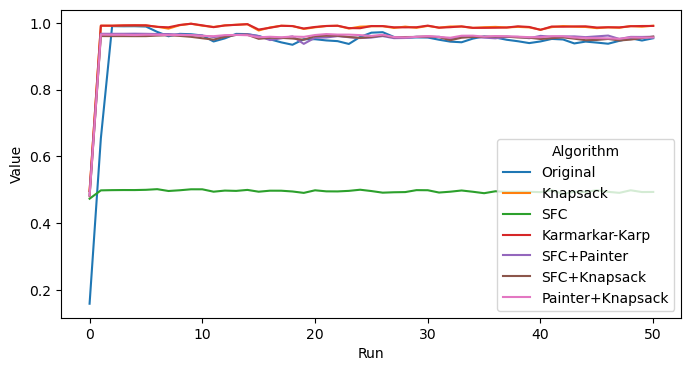

In [139]:
plt.figure(figsize=(8, 4))
# g = sns.FacetGrid(df_melted, col='Algorithm', col_wrap=3, height=5, aspect=1.2, sharey=True)
# g.map(sns.lineplot, 'Run', 'Value', 'Metric', markers=True, dashes=False, palette={'Efficiency': 'blue', 'PreviousEfficiency': 'orange'})
sns.lineplot(x='Run', y='Value', hue='Algorithm', data=df_melted, errorbar=None, markers=True, dashes=False)
# Show the plot
plt.show()

Let's get the weight distribution across different executions

In [120]:
inputs_path = '/home/jimlaudagostini/amrex_LB/input/'
input_files = []

for result in os.walk(inputs_path):
    if 'laser-ion-' in result[0]:
        for f in result[2]:
            if '.csv' in f and 'original' not in f:
                file = os.path.join(result[0], f)
                input_files.append(file)

def custom_sort(file_names):
    def parse_file_name(file_name):
        base_name = os.path.basename(file_name)
        match = re.match(r'laser-ion-(\d+)-(\d+)(.*)', base_name)
        if match:
            return (int(match.group(1)), int(match.group(2)))
        else:
            raise ValueError(f"Invalid file name format: {file_name}")

    return sorted(file_names, key=parse_file_name)

input_files = custom_sort(input_files)
input_files

['/home/jimlaudagostini/amrex_LB/input/laser-ion-8-1740/laser-ion-8-1740.csv',
 '/home/jimlaudagostini/amrex_LB/input/laser-ion-16-1740/laser-ion-16-1740.csv',
 '/home/jimlaudagostini/amrex_LB/input/laser-ion-32-1740/laser-ion-32-1740.csv',
 '/home/jimlaudagostini/amrex_LB/input/laser-ion-48-1740/laser-ion-48-1740.csv',
 '/home/jimlaudagostini/amrex_LB/input/laser-ion-96-1740/laser-ion-96-1740.csv']

In [156]:
to_concat = []

for result in input_files:
    df = pd.read_csv(input_files[0], header=None)
    df = df.iloc[::2]
    df = df.T.reset_index()
    df.columns = ['Box ID'] + [f'Step {i}' for i in range(51)]
    df = df.stack().reset_index()
    df.columns = ['Box ID', 'Step', 'Weight']
    
    df = df[df['Step'] != 'Box ID']
    df['Step'] = df['Step'].str.replace('Step ', '').astype(int)
    df['Step'] = df['Step'] * 100
    source = re.sub(".csv", "", os.path.basename(result))
    df['Source'] = re.sub("laser-ion-([0-9]*)-1740", r"\1", source)
    to_concat.append(df)

inputs_df = pd.concat(to_concat, ignore_index=True, axis=0)
inputs_df

,Box ID,Step,Weight,Source
0,0,0,28530.12,8
1,0,100,28513.02,8
2,0,200,28512.17,8
3,0,300,28468.56,8
4,0,400,28454.88,8
...,...,...,...,...
443695,1739,4600,3973.00,96
443696,1739,4700,3973.00,96
443697,1739,4800,3973.00,96
443698,1739,4900,3973.00,96


In [268]:
inputs_df.loc[:,'Log_Weight'] = np.log(inputs_df['Weight'])
df_count = inputs_df.groupby(['Source', 'Step', 'Log_Weight']).size().reset_index(name='Count')
df_8 = df_count[(df_count['Source'] == '8')]
filtered_df = df_8[df_8['Step'].isin([0, 100, 2500, 5000])]
filtered_df

,Source,Step,Log_Weight,Count
68037,8,0,8.287277,3
68038,8,0,8.564908,27
68039,8,0,8.947026,114
68040,8,0,9.224657,1026
68041,8,0,9.974619,3
...,...,...,...,...
90711,8,5000,13.441441,1
90712,8,5000,13.448236,1
90713,8,5000,13.534888,1
90714,8,5000,13.703496,1


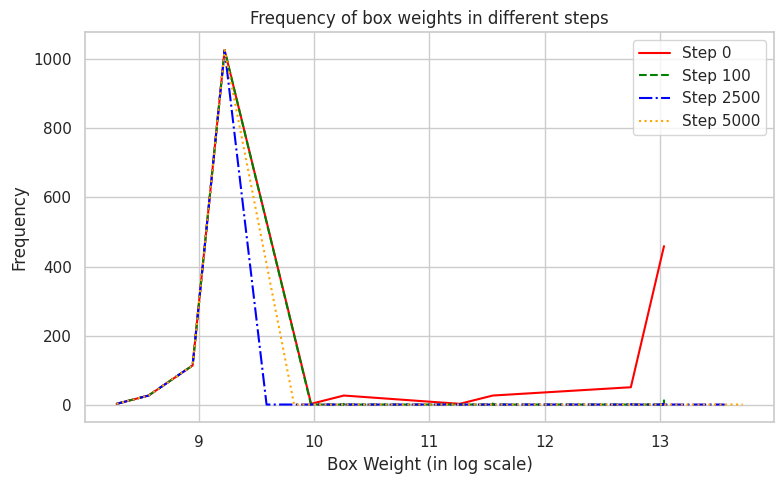

In [269]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
colors = ['red', 'green', 'blue', 'orange', 'pink']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1, 1, 1))]

for i, step in enumerate(filtered_df['Step'].unique()):
    source_df = filtered_df[filtered_df['Step'] == step]
    plt.plot(source_df['Log_Weight'], source_df['Count'], 
             label=f"Step {step}", 
             color=colors[i % len(colors)], 
             linestyle=linestyles[i % len(linestyles)])

plt.xlabel('Box Weight (in log scale)')
plt.ylabel('Frequency')
plt.title('Frequency of box weights in different steps')
plt.legend()
# tick_locations = np.linspace(min(filtered_df['Log_Weight']), max(filtered_df['Log_Weight']), 20)  # Show 10 ticks
# plt.xticks(tick_locations, rotation=45)
plt.tight_layout()
plt.savefig('freqeuncy_of_weights.png', dpi=300)
plt.show()

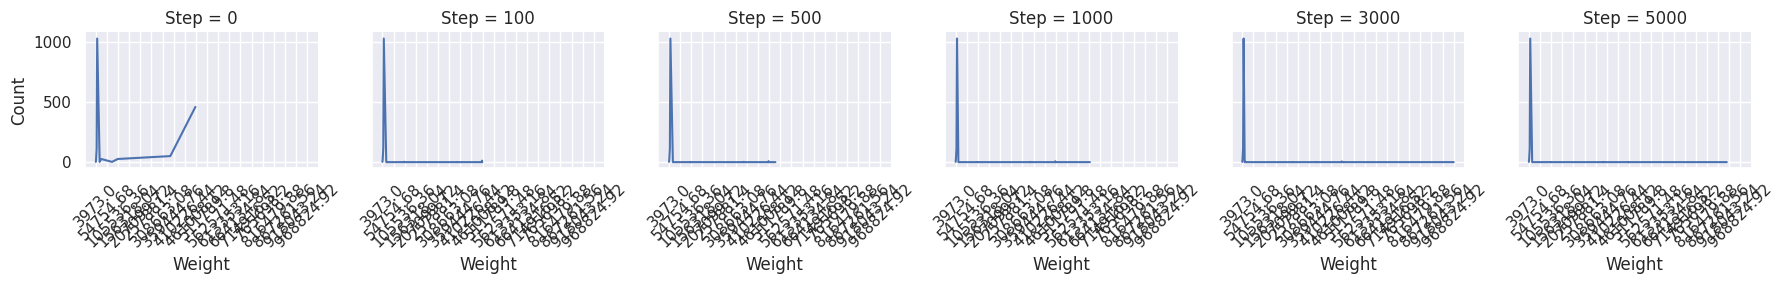

In [225]:
g = sns.FacetGrid(filtered_df, col="Step")
g.map(plt.plot, "Weight", "Count")

for ax in g.axes.flatten():
    ax.set_xticks(np.linspace(min(filtered_df['Weight']), max(filtered_df['Weight']), 20))
    ax.set_xticklabels(np.linspace(min(filtered_df['Weight']), max(filtered_df['Weight']), 20), rotation=45)

plt.tight_layout()
plt.show()